In [92]:
%load_ext autoreload
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(project_root)

from typing import Literal

from langchain_anthropic import ChatAnthropic 

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

from langgraph.constants import Send
from langgraph.graph import START, END, StateGraph
from langgraph.types import interrupt, Command

from src.open_deep_research.state import ReportStateInput, ReportStateOutput, Sections, ReportState, SectionState, SectionOutputState, Queries, Feedback
from src.open_deep_research.prompts import report_planner_query_writer_instructions, report_planner_instructions, query_writer_instructions, section_writer_instructions, final_section_writer_instructions, section_grader_instructions
from src.open_deep_research.configuration import Configuration
from src.open_deep_research.utils import tavily_search_async, deduplicate_and_format_sources, format_sections, perplexity_search, parse_llm_response, langfuse_handler


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:


TICKER_REPORT_STRUCTURE = """The report structure should focus on breaking-down the user-provided ticker:

1. Introduction (no research needed)
   - Short overview of the ticker/company

2. Fundamental Analysis
    - Fundamentals of the company
          - Include any key concepts and definitions
   - Provide real-world examples or case studies where applicable
   - Based on the fundamental data, give a score between 1(weakest)-10(strongest)

3. Recent events that have affected the company
    - Recent negative news
    - Recent positive news

4. Upcoming events and earnings
    - Negative news
    - Positive news
    - Based on the recent and upcoming news you have gathered and analyzed, give a ranking between Low, Medium and High risk for the event risk of the stock

5. Our Advanced Metrics 
    - Use the tool "call_api" to get our advanced metrics for this company
    - Provide a table of the metrics

6. Conclusion
   - Provide a concise summary of the report
   - Provide a table providing the scores and rankings

   """

async def generate_report_plan(state: ReportState, config: RunnableConfig):
    """ Generate the report plan """

    # Inputs
    topic = state["topic"]
    feedback = state.get("feedback_on_report_plan", None)

    # Get configuration
    configurable = Configuration.from_runnable_config(config)
    report_structure = configurable.report_structure
    number_of_queries = configurable.number_of_queries

    print(configurable)
    # Convert JSON object to string if necessary
    if isinstance(report_structure, dict):
        report_structure = str(report_structure)

    writer_model = ChatOpenAI(model=configurable.writer_model)

    # Generate search query
    # structured_llm = writer_model.with_structured_output(Queries)

    # Format system instructions
    system_instructions_query = report_planner_query_writer_instructions.format(topic=topic, report_organization=report_structure, number_of_queries=number_of_queries)

    print("system_instructions_query:", system_instructions_query)
    # Generate queries  
    raw_results = writer_model.invoke([HumanMessage(content=system_instructions_query)],config={"callbacks": [langfuse_handler]})
    print(raw_results)
    results = parse_llm_response(raw_results.content, Queries)
    print(results)

    # Web search
    query_list = [query.search_query for query in results.queries]

    # Handle both cases for search_api:
    # 1. When selected in Studio UI -> returns a string (e.g. "tavily")
    # 2. When using default -> returns an Enum (e.g. SearchAPI.TAVILY)
    if isinstance(configurable.search_api, str):
        search_api = configurable.search_api
    else:
        search_api = configurable.search_api.value

    # Search the web
    if search_api == "tavily":
        search_results = await tavily_search_async(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=False)
    elif search_api == "perplexity":
        search_results = perplexity_search(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=False)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    # Format system instructions
    system_instructions_sections = report_planner_instructions.format(topic=topic, report_organization=report_structure, context=source_str, feedback=feedback)
    print("system_instructions_sections:", system_instructions_sections)

    # Set the planner provider
    if isinstance(configurable.planner_provider, str):
        planner_provider = configurable.planner_provider
    else:
        planner_provider = configurable.planner_provider.value

    # Set the planner model
    if  planner_provider == "openai":
        planner_llm = ChatOpenAI(model=configurable.planner_model) 
    elif planner_provider == "groq":
        planner_llm = ChatGroq(model=configurable.planner_model)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    # Generate sections 
    # structured_llm = planner_llm.with_structured_output(Sections)
    report_sections = planner_llm.invoke([HumanMessage(content=system_instructions_sections)], config={"callbacks": [langfuse_handler]})
    print(report_sections)

    parsed = parse_llm_response(report_sections.content, Sections)
    print(parsed)
    # Get sections
    sections = parsed.sections

    return {"sections": sections}



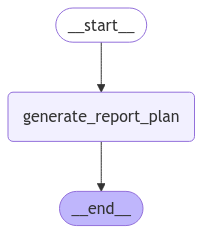

In [105]:
import asyncio
builder = StateGraph(ReportState, input=ReportStateInput, output=ReportStateOutput, config_schema=Configuration)
builder.add_node("generate_report_plan", generate_report_plan)
builder.add_edge(START, "generate_report_plan")
builder.add_edge("generate_report_plan", END)

from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))



In [106]:
import uuid
topic = "700 TENCENT"

# Fast config with o3-mini
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "report_structure": TICKER_REPORT_STRUCTURE,
                           "search_api": "tavily",
                           "planner_provider": "openai",
                           "max_search_depth": 1,
                           "writer_model": "o1-mini",
                           "planner_model": "o1-mini"}}

# Run the graph until the interruption
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    print(event)
    print("\n")

Configuration(report_structure='The report structure should focus on breaking-down the user-provided ticker:\n\n1. Introduction (no research needed)\n   - Short overview of the ticker/company\n\n2. Fundamental Analysis\n    - Fundamentals of the company\n          - Include any key concepts and definitions\n   - Provide real-world examples or case studies where applicable\n   - Based on the fundamental data, give a score between 1(weakest)-10(strongest)\n\n3. Recent events that have affected the company\n    - Recent negative news\n    - Recent positive news\n\n4. Upcoming events and earnings\n    - Negative news\n    - Positive news\n    - Based on the recent and upcoming news you have gathered and analyzed, give a ranking between Low, Medium and High risk for the event risk of the stock\n\n5. Our Advanced Metrics \n    - Use the tool "call_api" to get our advanced metrics for this company\n    - Provide a table of the metrics\n\n6. Conclusion\n   - Provide a concise summary of the re

In [ ]:
from src.open_deep_research.state import Section, Sections
import json
test = {'generate_report_plan': {'sections': [Section(name='Introduction', description='Short overview of the ticker/company.', research=False, content='', tools=False), Section(name='Fundamental Analysis', description="Analysis of the company's fundamentals, including key concepts and definitions, real-world examples or case studies, and an overall score based on the fundamental data.", research=True, content='', tools=False), Section(name='Recent events that have affected the company', description='Overview of recent negative and positive news impacting the company.', research=True, content='', tools=False), Section(name='Upcoming events and earnings', description='Information on upcoming negative and positive news, along with a risk ranking based on recent and upcoming news.', research=True, content='', tools=False), Section(name='Our Advanced Metrics', description='Advanced metrics for the company obtained through API calls and presented in a table format.', research=False, content='', tools=True), Section(name='Conclusion', description='Concise summary of the report, including a table of scores and rankings.', research=False, content='', tools=False)]}}
test

output = {'generate_report_plan': {'sections': [Section(name='Introduction', description='Short overview of the ticker/company.', research=False, content='', tools=False),
   Section(name='Fundamental Analysis', description="Analysis of the company's fundamentals, including key concepts and definitions, real-world examples or case studies, and an overall score based on the fundamental data.", research=True, content='', tools=False),
   Section(name='Recent events that have affected the company', description='Overview of recent negative and positive news impacting the company.', research=True, content='', tools=False),
   Section(name='Upcoming events and earnings', description='Information on upcoming negative and positive news, along with a risk ranking based on recent and upcoming news.', research=True, content='', tools=False),
   Section(name='Our Advanced Metrics', description='Advanced metrics for the company obtained through API calls and presented in a table format.', research=False, content='', tools=True),
   Section(name='Conclusion', description='Concise summary of the report, including a table of scores and rankings.', research=False, content='', tools=False)]}}

{'generate_report_plan': {'sections': [Section(name='Introduction', description='Short overview of the ticker/company.', research=False, content='', tools=False),
   Section(name='Fundamental Analysis', description="Analysis of the company's fundamentals, including key concepts and definitions, real-world examples or case studies, and an overall score based on the fundamental data.", research=True, content='', tools=False),
   Section(name='Recent events that have affected the company', description='Overview of recent negative and positive news impacting the company.', research=True, content='', tools=False),
   Section(name='Upcoming events and earnings', description='Information on upcoming negative and positive news, along with a risk ranking based on recent and upcoming news.', research=True, content='', tools=False),
   Section(name='Our Advanced Metrics', description='Advanced metrics for the company obtained through API calls and presented in a table format.', research=False, co

In [ ]:

def generate_queries(state: SectionState, config: RunnableConfig):
    """ Generate search queries for a report section """

    # Get state 
    section = state["section"]

    # Get configuration
    configurable = Configuration.from_runnable_config(config)
    writer_model = ChatOpenAI(model=configurable.writer_model)

    number_of_queries = configurable.number_of_queries

    # Generate queries 
    structured_llm = writer_model.with_structured_output(Queries)

    # Format system instructions
    system_instructions = query_writer_instructions.format(section_topic=section.description, number_of_queries=number_of_queries)

    # Generate queries  
    queries = structured_llm.invoke([SystemMessage(content=system_instructions)]+[HumanMessage(content="Generate search queries on the provided topic.")], config={"callbacks": [langfuse_handler]})

    return {"search_queries": queries.queries}

def write_section(state: SectionState, config: RunnableConfig) -> Command[Literal[END,"search_web"]]:
    """ Write a section of the report """

    # Get state 
    section = state["section"]
    source_str = state["source_str"]

    # Get configuration
    configurable = Configuration.from_runnable_config(config)
    writer_model = ChatOpenAI(model=configurable.writer_model)

    # Format system instructions
    system_instructions = section_writer_instructions.format(section_title=section.name, section_topic=section.description, context=source_str, section_content=section.content)

    # Generate section  
    section_content = writer_model.invoke([SystemMessage(content=system_instructions)]+[HumanMessage(content="Generate a report section based on the provided sources.")], config={"callbacks": [langfuse_handler]})
    print(section_content)

    # Write content to the section object  
    section.content = section_content.content

    # Grade prompt 
    section_grader_instructions_formatted = section_grader_instructions.format(section_topic=section.description,section=section.content)

    # Feedback 
    structured_llm = writer_model.with_structured_output(Feedback)
    feedback = structured_llm.invoke([SystemMessage(content=section_grader_instructions_formatted)]+[HumanMessage(content="Grade the report and consider follow-up questions for missing information:")], config={"callbacks": [langfuse_handler]})

    if feedback.grade == "pass" or state["search_iterations"] >= configurable.max_search_depth:
        # Publish the section to completed sections 
        return  Command(
        update={"completed_sections": [section]},
        goto=END
    )
    else:
        # Update the existing section with new content and update search queries
        return  Command(
        update={"search_queries": feedback.follow_up_queries, "section": section},
        goto="search_web"
        )

async def search_web(state: SectionState, config: RunnableConfig):
    """ Search the web for each query, then return a list of raw sources and a formatted string of sources."""
    
    # Get state 
    search_queries = state["search_queries"]

    # Get configuration
    configurable = Configuration.from_runnable_config(config)

    # Web search
    query_list = [query.search_query for query in search_queries]
    
    # Handle both cases for search_api:
    # 1. When selected in Studio UI -> returns a string (e.g. "tavily")
    # 2. When using default -> returns an Enum (e.g. SearchAPI.TAVILY)
    if isinstance(configurable.search_api, str):
        search_api = configurable.search_api
    else:
        search_api = configurable.search_api.value

    # Search the web
    if search_api == "tavily":
        search_results = await tavily_search_async(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=5000, include_raw_content=True)
    elif search_api == "perplexity":
        search_results = perplexity_search(query_list)
        source_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=5000, include_raw_content=False)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    return {"source_str": source_str, "search_iterations": state["search_iterations"] + 1}



In [ ]:

# Add nodes 
section_builder = StateGraph(SectionState, output=SectionOutputState)
section_builder.add_node("generate_queries", generate_queries)
section_builder.add_node("search_web", search_web)
section_builder.add_node("write_section", write_section)

# Add edges
section_builder.add_edge(START, "generate_queries")
section_builder.add_edge("generate_queries", "search_web")
section_builder.add_edge("search_web", "write_section")

# Pass True to approve the report plan 
async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

NameError: name 'generate_queries' is not defined

In [ ]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)